<a href="https://colab.research.google.com/github/So9912/Project6_Sofi/blob/main/Proyecto13_Sofia_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [ ]:
#Lectura de datos y Analisis exploratorio de datos
df= pd.read_csv('/content/drive/MyDrive/PROYECTOS TT/13. Pronosticos y predicciones/gym_churn_us.csv')
df.describe()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
mean_values = df.groupby('Churn').mean()
print(mean_values)

         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                                     
0                               2.0

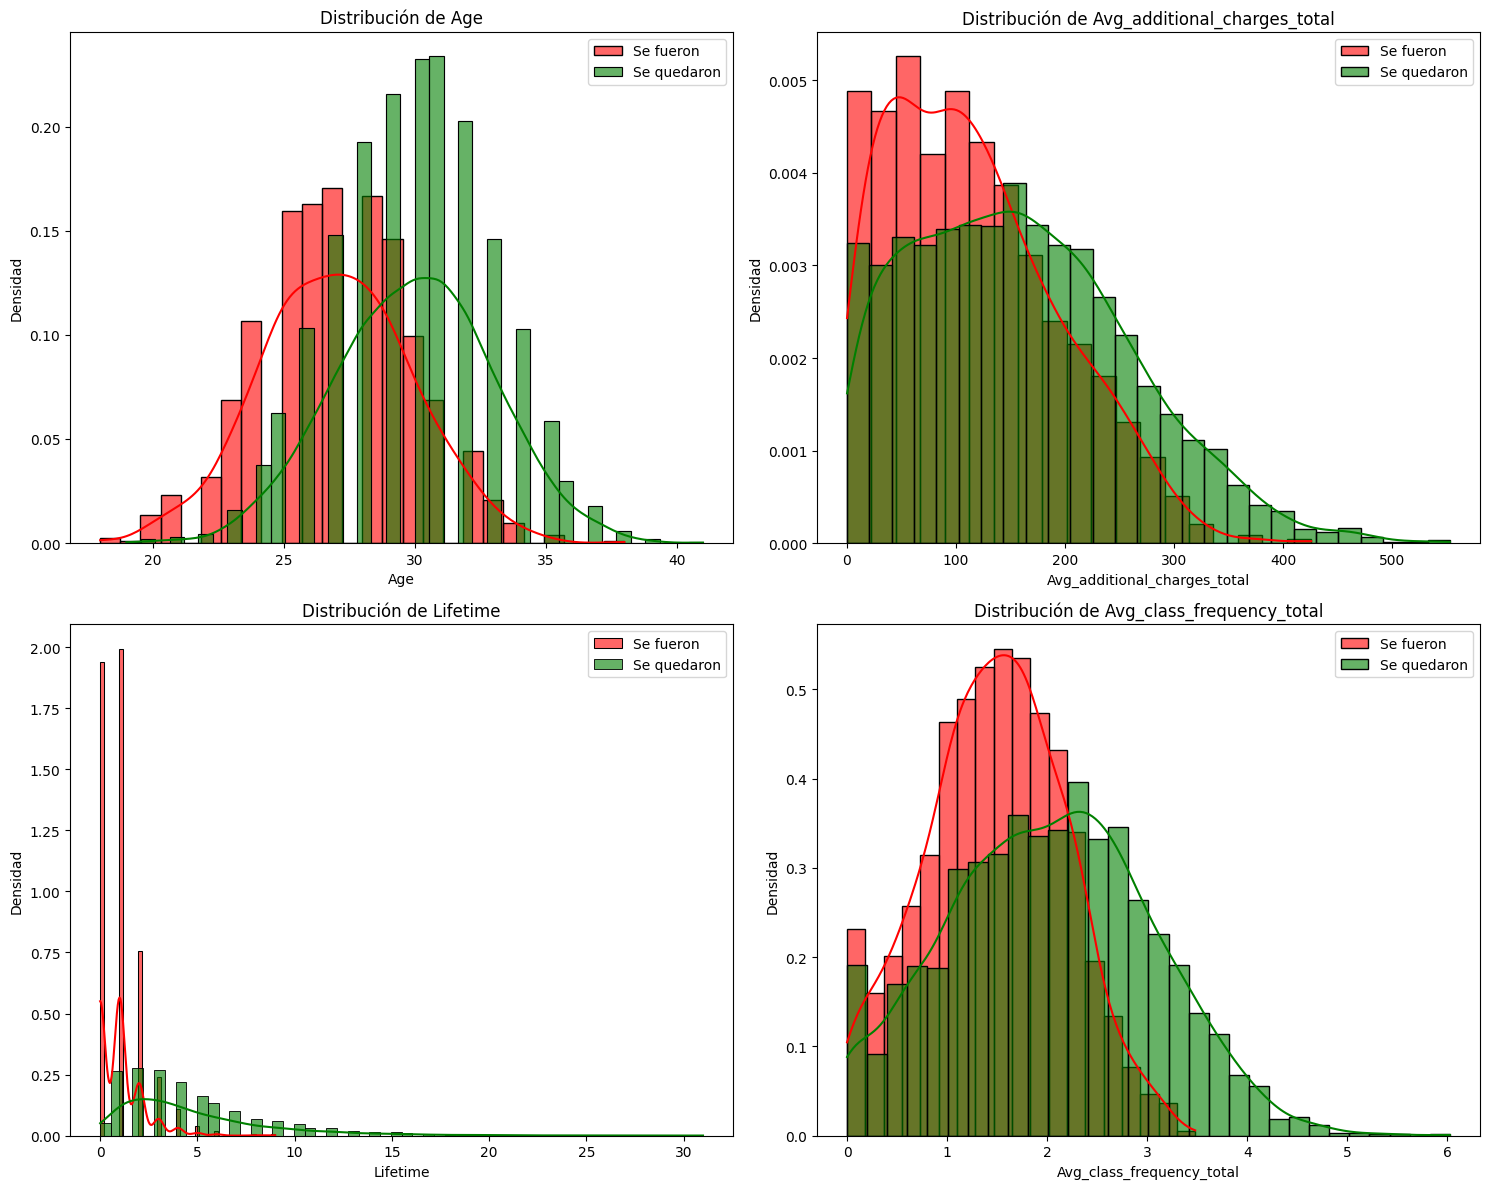

In [ ]:
df_left = df[df['Churn'] == 1]  # Los que se fueron
df_stayed = df[df['Churn'] == 0]  # Los que se quedaron


columns_to_plot = ['Age', 'Avg_additional_charges_total', 'Lifetime', 'Avg_class_frequency_total']

plt.figure(figsize=(15, 12))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_left[col], color='red', kde=True, stat='density', label='Se fueron', alpha=0.6)
    sns.histplot(df_stayed[col], color='green', kde=True, stat='density', label='Se quedaron', alpha=0.6)

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()


plt.tight_layout()
plt.show()

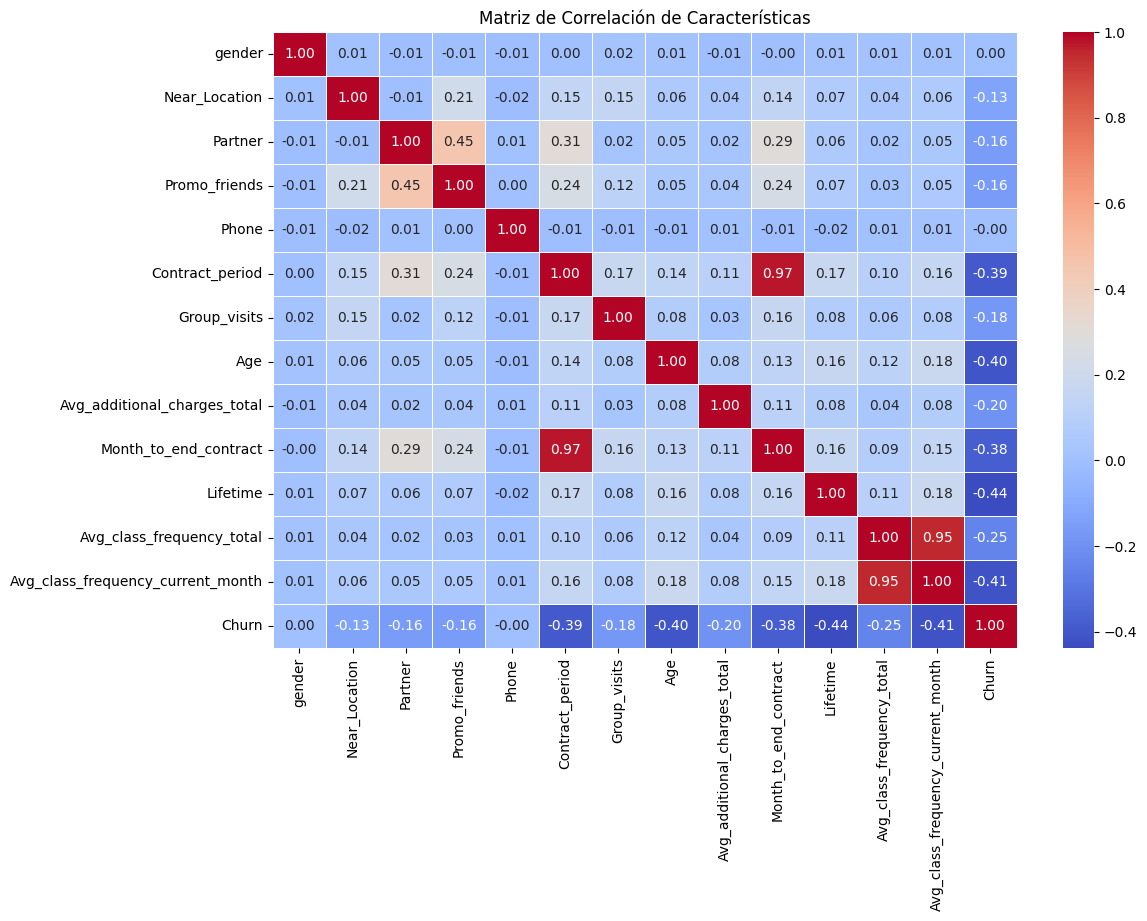

In [ ]:
# Calculamos la matriz de correlación
correlation_matrix = df.corr()

# Creamos un mapa de calor para visualizar la correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Matriz de Correlación de Características')
plt.show()


El mapa de calor se muestra la correlación de nuestros datos, donde podemos obervar las correlaciones negativas y positivas entre las variables, en este caso sólo tenemos valores de -4 a 1, siendo la relación mayor de los valores que más se acercan a 1 o -1(en este caso -4) lo que quiere decir que las relaciones negativas serán de bajas - moderadas que las positivas donde nuestro valor más alto si es 1 (positivo). De ella podemos resaltar una relación fuerte positiva entre el mes en el que termina el contrato y el perioro del contrato asi como la frecuencia en la que asisten los usuarios mismos que aparecen de color rojo (ignorando la línea) en el mapa de calor.

Construir un modelo para predecir la cancelación de usuarios

In [ ]:
# Seleccionamos las características (X) y la variable objetivo (y)
X = df.drop('Churn', axis=1)  # Eliminar la columna objetivo 'Churn'
y = df['Churn']  # La columna objetivo

# Tratamos con valores nulos
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Convertir las variables categóricas a variables dummy
X_encoded = pd.get_dummies(X_imputed, drop_first=True)

# Escalar las características (para la regresión logística)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# Dividir los datos en conjuntos de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Entrenamiento del modelo: Regresión Logística

In [ ]:
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# Predicciones en el conjunto de validación
y_pred_logreg = logreg.predict(X_val)

# Evaluación del modelo
accuracy_logreg = accuracy_score(y_val, y_pred_logreg)
precision_logreg = precision_score(y_val, y_pred_logreg)
recall_logreg = recall_score(y_val, y_pred_logreg)

print("Regresión Logística:")
print(f"Exactitud: {accuracy_logreg:.4f}")
print(f"Precisión: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")

Regresión Logística:
Exactitud: 0.9163
Precisión: 0.8729
Recall: 0.7822


Entrenamiento del modelo: Bosque Aleatorio


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predicciones en el conjunto de validación
y_pred_rf = rf.predict(X_val)

# Evaluación del modelo
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)

print("\nBosque Aleatorio:")
print(f"Exactitud: {accuracy_rf:.4f}")
print(f"Precisión: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")


Bosque Aleatorio:
Exactitud: 0.9100
Precisión: 0.8495
Recall: 0.7822


Comparación de los resultados

Exactitud: Proporción de predicciones correctas sobre el total de predicciones.
Precisión: Proporción de verdaderos positivos sobre todos los predichos como positivos. Es importante si deseas minimizar los falsos positivos.
Recall: Proporción de verdaderos positivos sobre todos los reales positivos. Es importante si deseas minimizar los falsos negativos.
La elección del modelo más adecuado depende de qué métrica consideres más importante para tu caso de uso.

Ya que  los modelos obtienen resultados similares, se utilizará el bosque aleatorio, ya que suele manejar mejor la no linealidad y las relaciones complejas entre características.

Crear clústeres de usuarios/as

In [ ]:
# Estandarizamos las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Visualizamos las primeras filas para confirmar la estandarización
print(pd.DataFrame(X_scaled, columns=X_encoded.columns).head())

     gender  Near_Location   Partner  Promo_friends     Phone  \
0  0.979706       0.427881  1.026861       1.497161 -3.059852   
1 -1.020715       0.427881 -0.973842      -0.667931  0.326813   
2 -1.020715       0.427881  1.026861      -0.667931  0.326813   
3 -1.020715       0.427881  1.026861       1.497161  0.326813   
4  0.979706       0.427881  1.026861       1.497161  0.326813   

   Contract_period  Group_visits       Age  Avg_additional_charges_total  \
0         0.289890      1.194032 -0.056554                     -1.377531   
1         1.608822      1.194032  0.557327                     -0.350213   
2        -0.809219     -0.837498 -0.363494                     -0.181592   
3         1.608822      1.194032  1.171208                     -0.874722   
4        -0.809219     -0.837498 -0.977375                      0.533700   

   Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
0               0.161605 -0.193329                  -1.911920   
1               1.8319

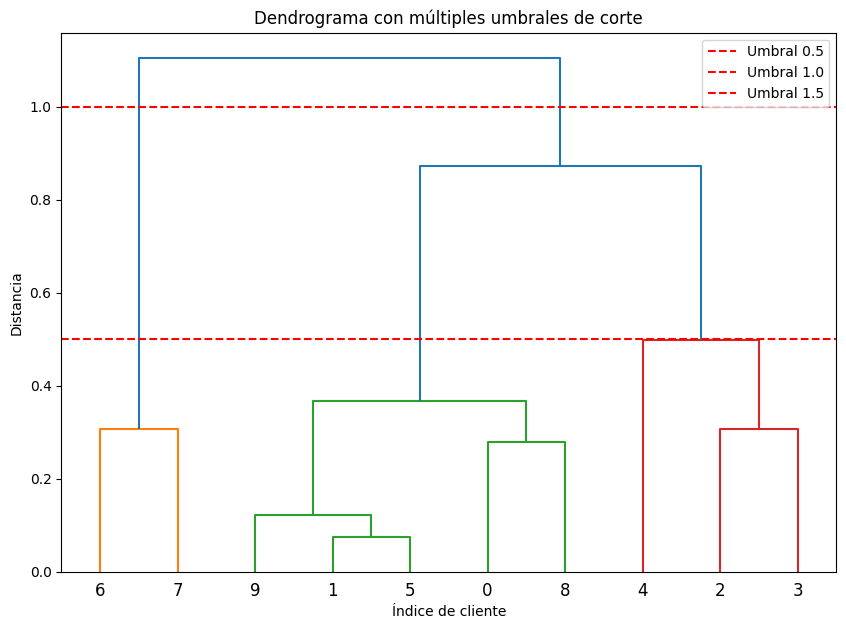

In [ ]:
X = np.random.rand(10, 2)
Z = linkage(X, method='ward')

umbrales = [0.5, 1.0, 1.5]  # Ajusta estos valores según el rango de tu dendrograma

plt.figure(figsize=(10, 7))
dendrogram(Z)

# Añadir líneas horizontales para los diferentes umbrales
for threshold in umbrales:
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Umbral {threshold}')

plt.title("Dendrograma con múltiples umbrales de corte")
plt.xlabel("Índice de cliente")
plt.ylabel("Distancia")
plt.legend()
plt.show()


En el dendrograma se puede obserrvar cómo es que se agrupan los usuarios de acuerdo con sus características y cómo es que a mayor altura de la línea, más diferentes son los grupos que se están uniendo.

Siendo los del nivel inferios(0.5) los más especificos y pequeños.
y el otro nivel que se logra visualizar los clústeres son más amplios:
Clúster 1: Clientes 6, 7, 9, 1, 5 y 0.
Clúster 2: Clientes 8.
Clúster 3: Clientes 4, 3 y 2.
Este umbral da una segmentación más equilibrada y puede ser útil para estrategias generales de interacción con grupos.

In [ ]:
conteo_clusters = Counter(clusters)
print("Distribución de clientes por clúster:", conteo_clusters)

Distribución de clientes por clúster: Counter({1: 10})


In [ ]:
# Crear el modelo de K-means con 5 clústeres
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# Predecir los clústeres de cada cliente
df['Cluster'] = kmeans.predict(X_scaled)

# Ver las primeras filas con el número de clúster asignado
print(df[['Cluster']].head())

   Cluster
0        1
1        3
2        0
3        2
4        1


In [ ]:
# Calcular las medias de las características para cada clúster
cluster_means = df.groupby('Cluster').mean()

print(cluster_means)


           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.484801       0.698363  0.301637       0.007015  0.899454   
1        0.494471       0.947867  0.791469       0.998420  0.906793   
2        0.464396       0.913313  0.766254       0.493808  0.925697   
3        0.547794       0.937500  0.742647       0.424632  0.863971   
4        0.568233       0.878076  0.178971       0.048098  0.914989   

         Contract_period  Group_visits        Age  \
Cluster                                             
0               1.733437      0.255651  28.074825   
1               2.740916      0.431280  28.903633   
2              10.495356      0.506192  30.091331   
3              11.194853      0.575368  29.720588   
4               2.120805      0.456376  29.993289   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                                                 

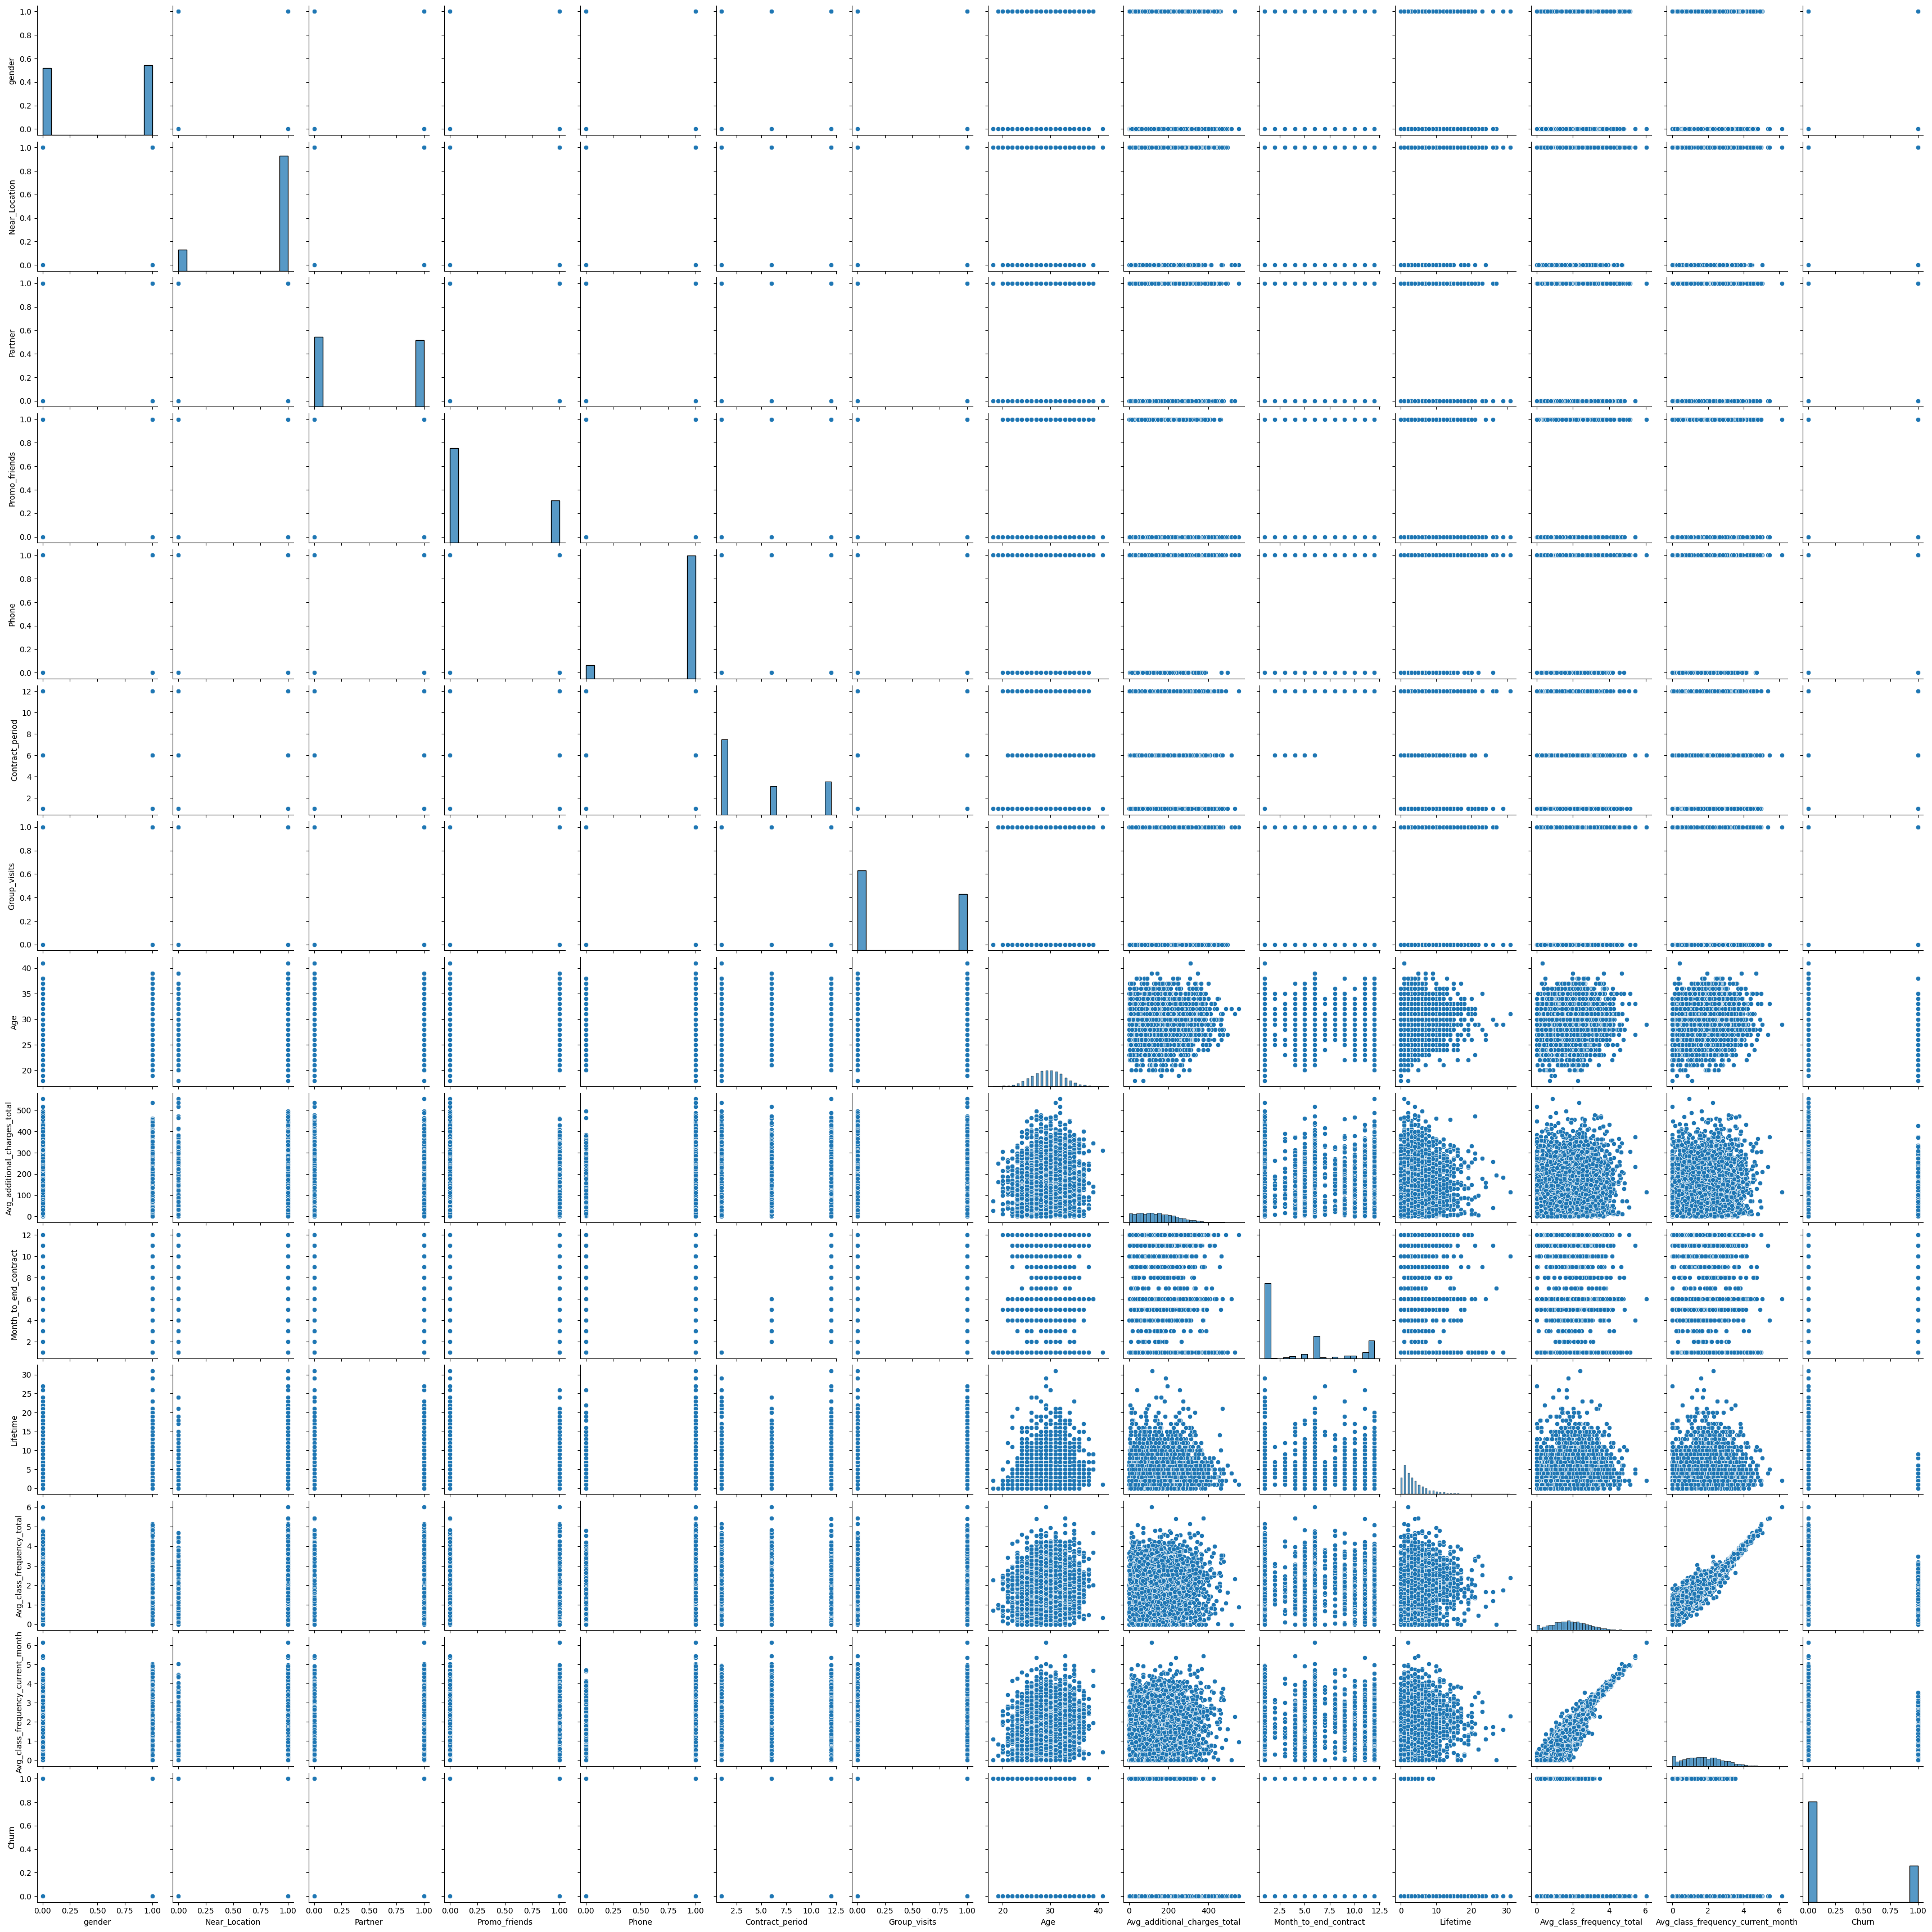

In [ ]:
sns.pairplot(df)
plt.show()

En las gráficas anteriores podemos observar cómo es que se relacionan algunas de las variables y cómo es que otra no muestran relación, siendo las que muestren puntos más visibles las que podrían tener una mayor relacion, aso como las que muestran una línea son aquellas que podrían tener una relación positiva, o negativa  como es el caso de la frecuencia con la que asisten al gimnasio los usuarios.

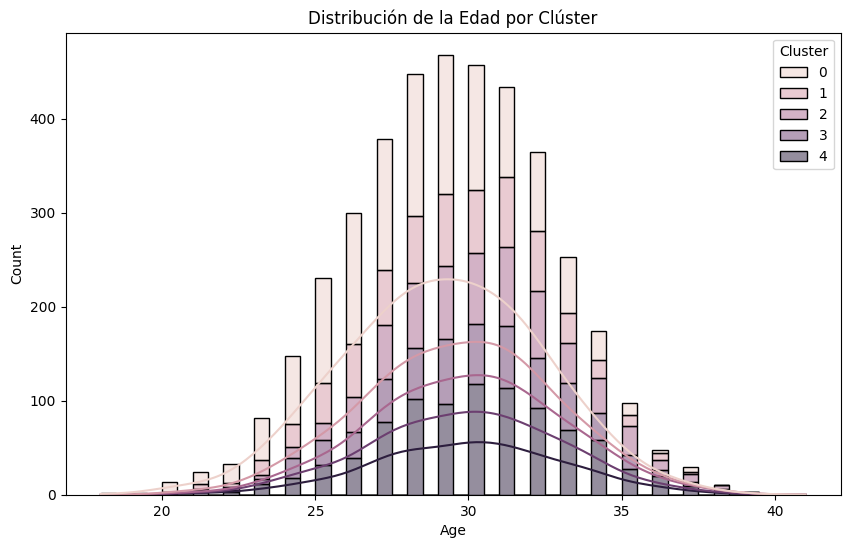

In [ ]:
# Graficar las distribuciones de una característica  para cada clúster
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Cluster', kde=True, multiple='stack')
plt.title('Distribución de la Edad por Clúster')
plt.show()


Adicionalmente se graficaron algunos parámetros para verla distribución por clúster, en cuanto a la edad se puede ver que la mayoría de nuestros usuarios en cada clúster o agrupación están entre los 30 años.

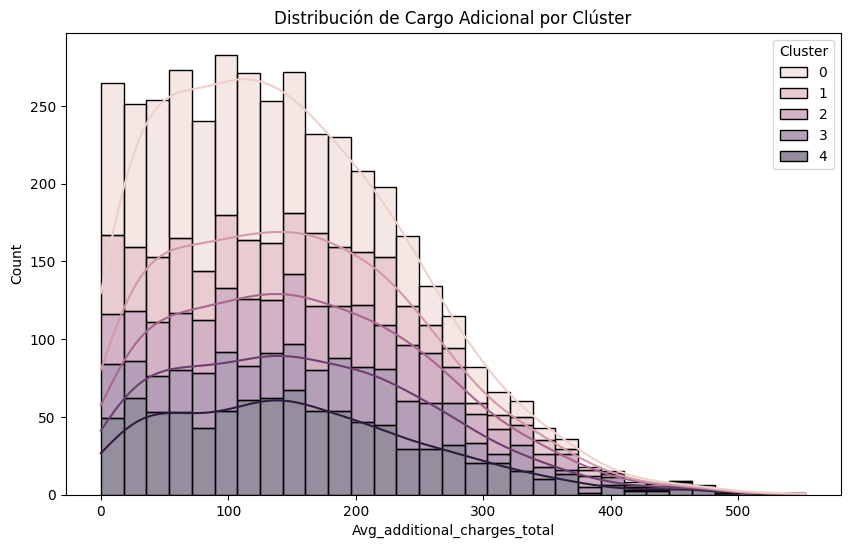

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Avg_additional_charges_total', hue='Cluster', kde=True, multiple='stack')
plt.title('Distribución de Cargo Adicional por Clúster')
plt.show()


En la gráfica podemos observar cómo nuestros datos estánalineados hacia a izquierda, donde se indica que los cargos adicionales en cada clúster son muy pocos.

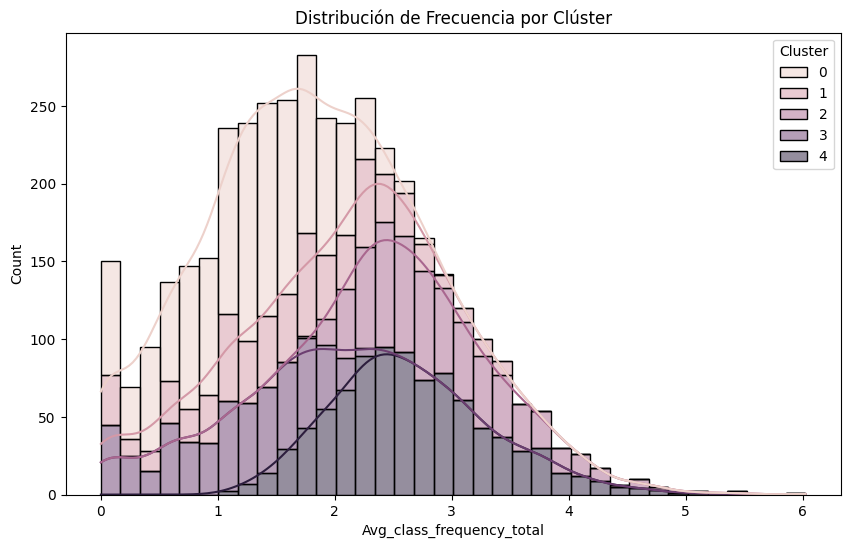

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Avg_class_frequency_total', hue='Cluster', kde=True, multiple='stack')
plt.title('Distribución de Frecuencia por Clúster')
plt.show()

En esta gráfima se muestra la distribución de la freceuncia con la que asiste los usuarios al gimnacio por clúster.

In [ ]:
# Calcular la tasa de cancelación para cada clúster
churn_rate_by_cluster = df.groupby('Cluster')['Churn'].mean()

print(churn_rate_by_cluster)


Cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: Churn, dtype: float64


## Conclusiones

Segmentación de Clientes (Clústeres):

Los clientes se agrupan en diferentes clústeres con características distintas. Esto sugiere que no todos los clientes son iguales y que una estrategia generalizada podría no ser tan efectiva como una personalizada para cada segmento.
Los clústeres pueden diferir en variables clave como la edad, el contrato, la frecuencia de visitas, los cargos adicionales y el tiempo de vida del cliente, lo que significa que las estrategias de retención deben ser específicas para cada grupo.

Tasa de Cancelación por Clúster:
Algunos clústeres muestran una tasa de cancelación significativamente más alta que otros. Esto indica que hay grupos de clientes más propensos a abandonar (churn) y otros más leales.
Los clientes de clústeres de mayor tasa de cancelación podrían estar experimentando problemas como insatisfacción con el servicio, contratos no adaptados a sus necesidades, o falta de interacción regular.

Características Relevantes:
Los clientes jóvenes podrían estar más comprometidos con la actividad, mostrando una alta frecuencia de visitas a las clases, mientras que los clientes más mayores podrían tener más dificultades para adaptarse a cambios o nuevas ofertas.
Los clientes con contratos más largos o aquellos que gastan más en cargos adicionales podrían tener una relación más estable con la empresa, pero también podrían estar más sensibles a cambios de precio o servicios.
Recomendaciones para la Estrategia de Interacción y Retención

Personalización de Ofertas según Clúster:
Clientes propensos a cancelar (Churn): Para los clústeres con una tasa de cancelación alta, se debe diseñar una estrategia de retención personalizada. Esto podría incluir ofertas especiales, descuentos exclusivos, o programas de fidelización. Además, se puede hacer un seguimiento personalizado para entender mejor las razones de su insatisfacción y evitar que se vayan.
Clientes leales: Para los clústeres con baja tasa de cancelación, sería beneficioso reforzar su lealtad mediante recompensas, acceso anticipado a nuevos servicios o productos, y destacando su importancia como cliente leal. También se puede premiar su fidelidad con programas de beneficios adicionales.

Ajuste de Contratos y Precios:
Para los clientes con contratos largos o altos gastos adicionales, se podría ofrecer planes de renovación con condiciones especiales, ofreciendo tarifas preferenciales o servicios adicionales a medida para aumentar su satisfacción y evitar que se vayan.
Clientes más jóvenes o con menos recursos podrían beneficiarse de planes más flexibles o precios más accesibles. Las ofertas de "pago por uso" o descuentos por referencias de amigos pueden ser útiles para estos segmentos.

Mejora de la Experiencia del Cliente:
Para aquellos clústeres con alta frecuencia de visitas a clases, puede ser útil ofrecer experiencias exclusivas como sesiones privadas o grupos de entrenamiento avanzados, para que se sientan valorados y continúen con su compromiso.
Clientes mayores o menos activos pueden necesitar una atención más personalizada. Programas de inducción, asesoramiento en el uso de los servicios, o incluso ajustes en la modalidad de clases podrían mejorar su experiencia y reducir la tasa de cancelación.
Programas de Fidelización:

Implementar un programa de fidelización que premie no solo la frecuencia, sino también la lealtad en el tiempo, y que esté adaptado a las necesidades de cada clúster.
Clientes de larga duración pueden recibir beneficios como descuentos exclusivos en cargos adicionales o en nuevas características del servicio.
Para clientes nuevos o con menos tiempo de relación, se pueden ofrecer incentivos como accesos gratis a clases adicionales o descuentos por traer amigos.

Optimización de la Comunicación:
Clientes con altas tasas de cancelación podrían beneficiarse de una comunicación más frecuente y personalizada. Esto puede incluir recordatorios de beneficios, ofertas exclusivas, o el contacto directo con un asesor.
En cambio, para clientes leales o aquellos con contratos más largos, mensajes de agradecimiento o reconocimiento por su fidelidad pueden fortalecer su relación con la marca.

Análisis Continuo:
Es fundamental realizar un monitoreo continuo de las tasas de cancelación, cambios en la frecuencia de visitas y otros comportamientos clave. Los clústeres podrían evolucionar con el tiempo, por lo que el análisis debe ser dinámico.
Implementar encuestas de satisfacción y feedback continuo para cada clúster ayudará a identificar áreas de mejora y ajustar la estrategia en tiempo real.
Conclusión General:
La segmentación de clientes en clústeres con características similares permite una estrategia más específica y adaptada a cada grupo. Esto resulta más eficaz que una aproximación única para todos.
Prestar atención a los clientes propensos a cancelar y ofrecerles incentivos adecuados, así como reforzar la relación con los clientes leales es clave para mejorar la retención.
Las ofertas personalizadas, los programas de fidelización y la comunicación constante son herramientas poderosas para aumentar el compromiso y evitar la pérdida de clientes.
Al aplicar estas recomendaciones, se puede mejorar la experiencia del cliente y reducir las tasas de cancelación, lo cual es fundamental para la sostenibilidad y el crecimiento de la empresa a largo plazo.